# Testing Hypervolume

In [1]:
# This code creates a reference set from the different seeds

# NOTE: For MMBorg archives, run the script to convert it to the format recognized by older code with ema-workbench.
# Example 
# python justice/util/borg_archive_processor.py     --archive /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/MOMA_DATA/200k/mm_intermediate.zip     --base-name MOMA_200000_ref2_555     --step 10000

from solvers.convergence.hypervolume import get_global_reference_set, calculate_hypervolume_from_archives
import multiprocessing
# Suppress warnings
import warnings

from justice.util.enumerations import WelfareFunction, SSP
from justice.util.visualizer import plot_hypervolume

warnings.filterwarnings("ignore")

base_path = "data/temporary/MOMA_DATA/200k" # Change this to your path

swf = WelfareFunction.UTILITARIAN
nfe = 200_000
ssp = SSP.SSP2
ssp_ref = 2
seed = 555
path = f"{base_path}/"
welfare_epsilon = 0.01


print(f"Loading data from {path}...")

list_of_objectives = [
    "macro_welfare_R5ASIA",
    "macro_welfare_R5LAM",
    "macro_welfare_R5MAF",
    "macro_welfare_R5OECD",
    "macro_welfare_R5REF",
    "fraction_above_threshold",
]
data_path = path 

direction_of_optimization = ["max", "max", "max", "max", "max", "min"] #, "max", "max"

get_global_reference_set(
    list_of_objectives=list_of_objectives,
    data_path=data_path,
    #file_name=None,
    swf="MOMA",
    nfe=str(nfe), # Ran for 50k number of function evaluations

    # Setting the same epsilon values as optimization process  (see analysis/analyzer.py)
    epsilons=[welfare_epsilon, welfare_epsilon, welfare_epsilon, welfare_epsilon, welfare_epsilon, 0.01],


    direction_of_optimization=direction_of_optimization,
    output_data_path=path,
    saving=True,
)




Loading data from data/temporary/MOMA_DATA/200k/...
Loading list of files
Loading archives for:  MOMA
Filename:  constrained_emission_control_rate2050.svg
Filename:  MOMA_200000_ref2_555_4.tar.gz
Matching file: MOMA_200000_ref2_555_4.tar.gz
Loading archives from: MOMA_200000_ref2_555_4.tar.gz
Max key: 200000
Number of rows in archive: 215
Archives loaded for: MOMA_200000_ref2_555_4.tar.gz
Filename:  MOMA_200000_ref2_555_8.tar.gz
Matching file: MOMA_200000_ref2_555_8.tar.gz
Loading archives from: MOMA_200000_ref2_555_8.tar.gz
Max key: 200000
Number of rows in archive: 151
Archives loaded for: MOMA_200000_ref2_555_8.tar.gz
Filename:  emissions_array_all_SSPs.npy
Filename:  .DS_Store
Filename:  AGENT_3
Filename:  AGENT_4
Filename:  emissions.npy
Filename:  AGENT_2
Filename:  MOMA_200000_ref2_555_6.tar.gz
Matching file: MOMA_200000_ref2_555_6.tar.gz
Loading archives from: MOMA_200000_ref2_555_6.tar.gz
Max key: 200000
Number of rows in archive: 226
Archives loaded for: MOMA_200000_ref2_555_

{'MOMA':       center 0 0  center 0 1  center 0 2  center 0 3  center 0 4  center 0 5  \
 271    -0.261397   -0.845849   -0.446200    0.696578   -0.575129   -0.123975   
 378     0.835504   -0.794113   -0.202966    0.252682    1.000000    0.019372   
 398     0.846091   -0.700169   -0.634098   -0.172482   -0.096287   -0.541458   
 470     0.835504    0.063049   -0.202966    0.119234    1.000000    0.094131   
 481     0.868882    0.966296   -0.195810    0.081261   -0.725715   -0.019878   
 542     0.823435   -0.739890   -0.459829   -0.060326    0.138701    0.017730   
 632     0.876854    0.294113    0.912465    0.057461    0.694486    0.131850   
 786    -0.218482    0.196151   -0.698695    0.036051    0.252648    0.543191   
 789     0.876854    0.294113    0.912465    0.057461    0.694486    0.131850   
 878     0.876854    0.294113    0.912465    0.057461    0.694486    0.131850   
 912    -0.951024    0.196151   -0.698695    0.036051    0.252648    0.543191   
 925    -0.807396   

In [2]:
# Read the reference set csv
import pandas as pd

path = "data/temporary/MOMA_DATA/200k" # Change this to your path

reference_set = pd.read_csv(f"{path}/MOMA_reference_set.csv")
# reference_set = pd.read_csv(f"{path}/200000.csv")

# Print reading from path and filename
# print(f"Reading reference set from {path}/MOMA_reference_set.csv")
# Print number of rows
print(f"Reference set size: {reference_set.shape[0]}")



df = reference_set

# Keep the last 6 columns
df_last6 = df.iloc[:, -6:]

# Print min and max of each of the last 6 columns
for column in df_last6.columns:
    print(f"{column}: min = {df_last6[column].min()}, max = {df_last6[column].max()}")
    # print difference between max and min
    print(f"{column}: range = {df_last6[column].max() - df_last6[column].min()}")


# Normalize the last 6 columns between 0 and 1
df_normalized = df_last6.copy()
for column in df_normalized.columns:
    min_val = df_normalized[column].min()
    max_val = df_normalized[column].max()
    df_normalized[column] = (df_normalized[column] - min_val) / (max_val - min_val)

# Use plotly to create a parallel axes plot
import plotly.express as px
fig = px.parallel_coordinates(
    df_normalized,
    dimensions=df_normalized.columns,
    title="Parallel Coordinates Plot of Normalized Objectives",
)
fig.show()

df.columns


Reference set size: 51
macro_welfare_R5ASIA: min = 1638.5981893114918, max = 1707.0186997153098
macro_welfare_R5ASIA: range = 68.42051040381807
macro_welfare_R5LAM: min = 2859.0304241746553, max = 3027.1308674495876
macro_welfare_R5LAM: range = 168.10044327493233
macro_welfare_R5MAF: min = 2058.2629841703765, max = 2153.498703036129
macro_welfare_R5MAF: range = 95.23571886575246
macro_welfare_R5OECD: min = 3357.8696871012016, max = 3435.409309289098
macro_welfare_R5OECD: range = 77.53962218789638
macro_welfare_R5REF: min = 2100.5672997542224, max = 2197.326614048576
macro_welfare_R5REF: range = 96.75931429435377
fraction_above_threshold: min = 0.4199999999999999, max = 0.8599999999999999
fraction_above_threshold: range = 0.44


Index(['center 0 0', 'center 0 1', 'center 0 2', 'center 0 3', 'center 0 4',
       'center 0 5', 'center 0 6', 'center 0 7', 'center 0 8', 'center 0 9',
       ...
       'weights 4 1', 'weights 4 2', 'weights 4 3', 'weights 4 4',
       'macro_welfare_R5ASIA', 'macro_welfare_R5LAM', 'macro_welfare_R5MAF',
       'macro_welfare_R5OECD', 'macro_welfare_R5REF',
       'fraction_above_threshold'],
      dtype='object', length=181)

In [2]:
from solvers.convergence.pareto import eps_sort
import numpy as np
import pandas as pd


path = "data/temporary/MOMA_DATA/200k"
filename = "MOMA_reference_set.csv" #"MOMA_reference_set.csv" #"MOMA_reference_set_SORTED.csv" #"MOMA_combined_reference_set_9_islands.csv"
df = pd.read_csv(f"{path}/{filename}")

objectives = [
    "macro_welfare_R5ASIA",
    "macro_welfare_R5LAM",
    "macro_welfare_R5MAF",
    "macro_welfare_R5OECD",
    "macro_welfare_R5REF",
    "fraction_above_threshold",
]

# Insert the DataFrame index as the first column so we can recover row numbers.
table = df.reset_index()[["index"] + objectives].to_numpy()

epsilons = [0.001, 0.001, 0.001, 0.001, 0.001, 0.001]
maximize_cols = [1, 2, 3, 4, 5]  # columns to maximize (column 6 will be minimized)

# Run epsilon-nondominated sorting.
tagalongs = eps_sort(
    table,
    objectives=[1, 2, 3, 4, 5, 6],
    epsilons=epsilons,
    maximize=maximize_cols,
)

# The first column contains the original row indices.
# pareto_idx = np.unique(tagalongs[:, 0].astype(int))
# pareto_front_df = df.loc[pareto_idx].copy()

# print(f"Found {len(pareto_front_df)} ε-nondominated policies.")


In [3]:
import pandas as pd
import numpy as np

# Define which objectives belong to which agent
agent_objectives = {
    "agent_1": ["macro_welfare_R5ASIA", "fraction_above_threshold"],
    "agent_2": ["macro_welfare_R5LAM", "fraction_above_threshold"],
    "agent_3": ["macro_welfare_R5MAF", "fraction_above_threshold"],
    "agent_4": ["macro_welfare_R5OECD", "fraction_above_threshold"],
    "agent_5": ["macro_welfare_R5REF", "fraction_above_threshold"],
}


num_agents = 5
num_solutions = len(df)


def is_pareto_dominated(solution_idx, agent_name, df, agent_objectives, 
                         minimize_objectives=["fraction_above_threshold"]):
    """
    Check if solution_idx is Pareto-dominated by any other solution
    for the given agent's objectives.
    
    minimize_objectives: list of objectives to MINIMIZE (rest are maximized)
    
    Returns: True if dominated, False if non-dominated
    """
    objectives = agent_objectives[agent_name]
    
    # Get this solution's outcome for this agent
    solution_outcome = df.loc[solution_idx, objectives].values
    
    # Compare against all other solutions
    for other_idx in range(len(df)):
        if other_idx == solution_idx:
            continue
        
        other_outcome = df.loc[other_idx, objectives].values
        
        # Check Pareto dominance considering min/max per objective
        at_least_as_good = True
        strictly_better = False
        
        for i, obj in enumerate(objectives):
            if obj in minimize_objectives:
                # For minimization: lower is better
                if other_outcome[i] > solution_outcome[i]:
                    # other is worse (higher) on this minimization objective
                    at_least_as_good = False
                    break
                elif other_outcome[i] < solution_outcome[i]:
                    # other is better (lower) on this minimization objective
                    strictly_better = True
            else:
                # For maximization: higher is better
                if other_outcome[i] < solution_outcome[i]:
                    # other is worse (lower) on this maximization objective
                    at_least_as_good = False
                    break
                elif other_outcome[i] > solution_outcome[i]:
                    # other is better (higher) on this maximization objective
                    strictly_better = True
        
        if at_least_as_good and strictly_better:
            # other_outcome dominates solution_outcome
            return True
    
    return False

# ============================================================
# STAGE 2: Check Pareto-Nash for each solution and each agent
# ============================================================

pareto_nash_set = []

for solution_idx in range(num_solutions):
    is_pareto_nash = True
    
    # Check all agents
    for agent_name in agent_objectives.keys():
        
        # Check if this solution is Pareto-dominated for this agent
        if is_pareto_dominated(solution_idx, agent_name, df, agent_objectives,
                               minimize_objectives=["fraction_above_threshold"]):

            is_pareto_nash = False
            break
    
    if is_pareto_nash:
        pareto_nash_set.append(solution_idx)
        print(f"Solution {solution_idx} is PARETO-NASH ✓")

print(f"\nPareto-Nash set: {pareto_nash_set}")

# Print the last 6 columns of the Pareto-Nash front
pareto_solution = df.loc[pareto_nash_set]
# Extract the last 6 columns
pareto_solution_last6 = pareto_solution.iloc[:, -6:]
print(f"Pareto-Nash front (last 6 objectives):\n{pareto_solution_last6}")

df.columns

#Pareto-Nash front (last 6 objectives):
#     macro_welfare_R5ASIA  macro_welfare_R5LAM  macro_welfare_R5MAF  \
# 26             1707.0187          3027.130867          2137.421176   

#     macro_welfare_R5OECD  macro_welfare_R5REF  fraction_above_threshold  
# 26             3372.8681          2145.106776                      0.42  

Solution 26 is PARETO-NASH ✓

Pareto-Nash set: [26]
Pareto-Nash front (last 6 objectives):
    macro_welfare_R5ASIA  macro_welfare_R5LAM  macro_welfare_R5MAF  \
26             1707.0187          3027.130867          2137.421176   

    macro_welfare_R5OECD  macro_welfare_R5REF  fraction_above_threshold  
26             3372.8681          2145.106776                      0.42  


Index(['center 0 0', 'center 0 1', 'center 0 2', 'center 0 3', 'center 0 4',
       'center 0 5', 'center 0 6', 'center 0 7', 'center 0 8', 'center 0 9',
       ...
       'weights 4 1', 'weights 4 2', 'weights 4 3', 'weights 4 4',
       'macro_welfare_R5ASIA', 'macro_welfare_R5LAM', 'macro_welfare_R5MAF',
       'macro_welfare_R5OECD', 'macro_welfare_R5REF',
       'fraction_above_threshold'],
      dtype='object', length=181)

# Table Nash

In [12]:
import numpy as np
import pandas as pd


import re
from collections import defaultdict

def build_strategy_cols_by_agent(df, num_agents=5):
    """
    Detect strategy columns of the form:
      'center i j' or 'centers i j' or 'weights i j'
    where i is agent id in [0..num_agents-1].
    """
    pat = re.compile(r"^(center|centers|weights)\s+(\d+)\s+(\d+)$")

    strat = defaultdict(list)
    for c in df.columns:
        m = pat.match(c)
        if not m:
            continue
        agent_id = int(m.group(2))
        if 0 <= agent_id < num_agents:
            strat[f"agent_{agent_id+1}"].append(c)

    # sanity
    for i in range(num_agents):
        key = f"agent_{i+1}"
        if key not in strat or len(strat[key]) == 0:
            raise ValueError(f"No strategy columns detected for {key}. Check column naming.")

    return dict(strat)

strategy_cols_by_agent = build_strategy_cols_by_agent(df, num_agents=5)

for a, cols in strategy_cols_by_agent.items():
    print(a, len(cols), "strategy cols")



# --- your objective mapping (given) ---
agent_objectives = {
    "agent_1": ["macro_welfare_R5ASIA", "fraction_above_threshold"],
    "agent_2": ["macro_welfare_R5LAM",  "fraction_above_threshold"],
    "agent_3": ["macro_welfare_R5MAF",  "fraction_above_threshold"],
    "agent_4": ["macro_welfare_R5OECD", "fraction_above_threshold"],
    "agent_5": ["macro_welfare_R5REF",  "fraction_above_threshold"],
}

# YOU must define this based on your dataframe columns:
# strategy_cols_by_agent = {
#     "agent_1": [...],  # all RBF hyperparameter columns for agent 1
#     "agent_2": [...],
#     ...
# }

def dominated_flags_in_group_2d(g, w_col, t_col, tol_w=0.0, tol_t=0.0):
    """
    Within a group where s_-i is fixed, mark rows that are Pareto-dominated
    for the 2D objective (maximize w_col, minimize t_col).

    Row a dominates row b if:
      w_a >= w_b - tol_w
      t_a <= t_b + tol_t
      and at least one strict (with tolerances).
    """
    if len(g) <= 1:
        return pd.Series(False, index=g.index)

    # Sort so that as we move forward, t is nondecreasing (worse or equal),
    # and for ties in t, higher welfare comes first
    gs = g.sort_values([t_col, w_col], ascending=[True, False])

    # 1) Dominated by same-t rows: if someone has same t and strictly higher w
    max_w_at_t = gs.groupby(t_col)[w_col].transform("max")
    dom_same_t = max_w_at_t > gs[w_col] + tol_w

    # 2) Dominated by strictly smaller t rows: if there exists t' < t with w' >= w
    # Build table of unique t values and the best welfare at each t
    t_best = gs.groupby(t_col, sort=True)[w_col].max().reset_index()
    # For each t, best welfare achievable at any strictly smaller t
    t_best["best_w_prev_t"] = t_best[w_col].cummax().shift(1).fillna(-np.inf)
    prev_map = dict(zip(t_best[t_col].values, t_best["best_w_prev_t"].values))

    best_w_with_smaller_t = gs[t_col].map(prev_map)
    dom_smaller_t = best_w_with_smaller_t >= gs[w_col] - tol_w

    dominated = dom_same_t | dom_smaller_t

    # return aligned to original g index
    return dominated.reindex(g.index, fill_value=False)

def find_pareto_nash_table(
    df,
    agent_objectives,
    strategy_cols_by_agent,
    round_decimals=6,          # key practical knob for "same s_-i"
    tol_w=0.0,
    tol_t=0.0,
):
    """
    Returns indices of rows that are Pareto–Nash *with respect to the rows present in df*.

    Important: This only tests deviations that exist in the table (after rounding),
    not all possible continuous deviations.
    """
    df2 = df.copy()

    # sanity: ensure all needed cols exist
    all_strategy_cols = [c for cols in strategy_cols_by_agent.values() for c in cols]
    missing = [c for c in all_strategy_cols if c not in df2.columns]
    if missing:
        raise ValueError(f"Missing strategy columns in df: {missing[:10]} ...")

    # rounding makes "others fixed" grouping feasible in continuous space
    if round_decimals is not None:
        df2[all_strategy_cols] = df2[all_strategy_cols].round(round_decimals)

    dominated_by_agent = {}

    # For each agent i: group rows by s_-i and check dominance within each group
    agents = list(agent_objectives.keys())
    for agent in agents:
        w_col, t_col = agent_objectives[agent]

        others_cols = []
        for a2 in agents:
            if a2 != agent:
                others_cols.extend(strategy_cols_by_agent[a2])

        # Hash key for "others fixed"
        # (hashing is much faster than using tuples of many float columns)
        key = pd.util.hash_pandas_object(df2[others_cols], index=False)
        df2[f"_key_{agent}"] = key

        dom_flags = pd.Series(False, index=df2.index)

        for _, g in df2.groupby(f"_key_{agent}", sort=False):
            dom_g = dominated_flags_in_group_2d(g, w_col=w_col, t_col=t_col, tol_w=tol_w, tol_t=tol_t)
            dom_flags.loc[g.index] = dom_g

        dominated_by_agent[agent] = dom_flags

    # Pareto–Nash rows: not dominated for any agent within their unilateral deviation sets
    dom_any = np.zeros(len(df2), dtype=bool)
    for agent in agents:
        dom_any |= dominated_by_agent[agent].to_numpy()

    pareto_nash_idx = df2.index[~dom_any].tolist()
    return pareto_nash_idx, dominated_by_agent



pn_idx = find_pareto_nash_table(
    df,
    agent_objectives=agent_objectives,
    strategy_cols_by_agent=strategy_cols_by_agent,
    round_decimals=6,   # tune this
)

print("Pareto–Nash candidates (table-based):", pn_idx)

agent_1 20 strategy cols
agent_2 20 strategy cols
agent_3 20 strategy cols
agent_4 20 strategy cols
agent_5 20 strategy cols


/var/folders/l1/cbpvtb4x2c38sfgzlzdply84c5jfvg/T/ipykernel_3890/1192096297.py:133: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/l1/cbpvtb4x2c38sfgzlzdply84c5jfvg/T/ipykernel_3890/1192096297.py:133: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/l1/cbpvtb4x2c38sfgzlzdply84c5jfvg/T/ipykernel_3890/1192096297.py:133: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd

Pareto–Nash candidates (table-based): ([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47], {'agent_1': 0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13     True
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47    False
dtype: bool, 'agent_2': 0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13     True
14   

In [9]:
import pandas as pd
import numpy as np


# Define which objectives belong to which agent
agent_objectives = {
    "agent_1": ["macro_welfare_R5ASIA", "fraction_above_threshold"],
    "agent_2": ["macro_welfare_R5LAM", "fraction_above_threshold"],
    "agent_3": ["macro_welfare_R5MAF", "fraction_above_threshold"],
    "agent_4": ["macro_welfare_R5OECD", "fraction_above_threshold"],
    "agent_5": ["macro_welfare_R5REF", "fraction_above_threshold"],
}

num_agents = 5
num_solutions = len(df)

def is_pareto_dominated(solution_idx, agent_name, df, agent_objectives, 
                         minimize_objectives=["fraction_above_threshold"],
                         verbose=False):
    """
    Check if solution_idx is Pareto-dominated by any other solution
    for the given agent's objectives.
    
    minimize_objectives: list of objectives to MINIMIZE (rest are maximized)
    verbose: if True, print detailed comparison
    
    Returns: True if dominated, False if non-dominated
    """
    objectives = agent_objectives[agent_name]
    
    # Get this solution's outcome for this agent
    solution_outcome = df.loc[solution_idx, objectives].values
    
    if verbose:
        print(f"\n  Checking {agent_name}")
        print(f"    Original solution {solution_idx}: {solution_outcome}")
        print(f"    Objectives: {objectives}")
    
    # Compare against all other solutions
    for other_idx in range(len(df)):
        if other_idx == solution_idx:
            continue
        
        other_outcome = df.loc[other_idx, objectives].values
        
        # Check Pareto dominance considering min/max per objective
        at_least_as_good = True
        strictly_better = False
        comparison_details = []
        
        for i, obj in enumerate(objectives):
            if obj in minimize_objectives:
                # For minimization: lower is better
                if other_outcome[i] > solution_outcome[i]:
                    # other is worse (higher) on this minimization objective
                    at_least_as_good = False
                    comparison_details.append(f"{obj}: {other_outcome[i]:.4f} > {solution_outcome[i]:.4f} (other WORSE)")
                    break
                elif other_outcome[i] < solution_outcome[i]:
                    # other is better (lower) on this minimization objective
                    strictly_better = True
                    comparison_details.append(f"{obj}: {other_outcome[i]:.4f} < {solution_outcome[i]:.4f} (other BETTER)")
                else:
                    # Equal
                    comparison_details.append(f"{obj}: {other_outcome[i]:.4f} = {solution_outcome[i]:.4f} (EQUAL)")
            else:
                # For maximization: higher is better
                if other_outcome[i] < solution_outcome[i]:
                    # other is worse (lower) on this maximization objective
                    at_least_as_good = False
                    comparison_details.append(f"{obj}: {other_outcome[i]:.4f} < {solution_outcome[i]:.4f} (other WORSE)")
                    break
                elif other_outcome[i] > solution_outcome[i]:
                    # other is better (higher) on this maximization objective
                    strictly_better = True
                    comparison_details.append(f"{obj}: {other_outcome[i]:.4f} > {solution_outcome[i]:.4f} (other BETTER)")
                else:
                    # Equal
                    comparison_details.append(f"{obj}: {other_outcome[i]:.4f} = {solution_outcome[i]:.4f} (EQUAL)")
        
        if verbose:
            print(f"      vs Solution {other_idx}: {other_outcome}")
            for detail in comparison_details:
                print(f"        {detail}")
        
        if at_least_as_good and strictly_better:
            # other_outcome dominates solution_outcome
            if verbose:
                print(f"      ✗ DOMINATES! Solution {other_idx} Pareto-dominates solution {solution_idx}")
            return True
        elif verbose and not at_least_as_good:
            print(f"      ✓ Does NOT dominate (other is worse on some objective)")
    
    return False


# ============================================================
# STAGE 2: Check Pareto-Nash for each solution and each agent
# ============================================================

pareto_nash_set = []

for solution_idx in range(num_solutions):
    is_pareto_nash = True
    
    print(f"\n{'='*80}")
    print(f"TESTING SOLUTION {solution_idx}")
    print(f"{'='*80}")
    
    # Check all agents
    for agent_name in agent_objectives.keys():
        
        # Check if this solution is Pareto-dominated for this agent
        if is_pareto_dominated(solution_idx, agent_name, df, agent_objectives,
                               minimize_objectives=["fraction_above_threshold"],
                               verbose=True):
            
            print(f"\n  ✗ Solution {solution_idx} is NOT Pareto-Nash for {agent_name}")
            print(f"     (Agent {agent_name} found a unilateral improvement)")
            is_pareto_nash = False
            break
        else:
            print(f"\n  ✓ Solution {solution_idx} is NON-DOMINATED for {agent_name}")
            print(f"     (Agent {agent_name} cannot improve unilaterally)")
    
    if is_pareto_nash:
        pareto_nash_set.append(solution_idx)
        print(f"\n{'='*80}")
        print(f"✓✓✓ Solution {solution_idx} is PARETO-NASH ✓✓✓")
        print(f"{'='*80}")


print(f"\n\n{'='*80}")
print(f"FINAL RESULT")
print(f"{'='*80}")
print(f"Pareto-Nash set: {pareto_nash_set}")
print(f"\nPareto-Nash front:\n{df.loc[pareto_nash_set]}")



TESTING SOLUTION 0

  Checking agent_1
    Original solution 0: [2.12332162e+03 6.80000000e-01]
    Objectives: ['macro_welfare_R5ASIA', 'fraction_above_threshold']
      vs Solution 1: [2.06694569e+03 7.60000000e-01]
        macro_welfare_R5ASIA: 2066.9457 < 2123.3216 (other WORSE)
      ✓ Does NOT dominate (other is worse on some objective)
      vs Solution 2: [2.0709128e+03 7.4000000e-01]
        macro_welfare_R5ASIA: 2070.9128 < 2123.3216 (other WORSE)
      ✓ Does NOT dominate (other is worse on some objective)
      vs Solution 3: [2.09603438e+03 6.40000000e-01]
        macro_welfare_R5ASIA: 2096.0344 < 2123.3216 (other WORSE)
      ✓ Does NOT dominate (other is worse on some objective)
      vs Solution 4: [2.09011268e+03 6.00000000e-01]
        macro_welfare_R5ASIA: 2090.1127 < 2123.3216 (other WORSE)
      ✓ Does NOT dominate (other is worse on some objective)
      vs Solution 5: [2.0796573e+03 6.6000000e-01]
        macro_welfare_R5ASIA: 2079.6573 < 2123.3216 (other WORSE)

Top indices: {'MOMA_combined_reference_set_9_islands.csv': [1230]}
Size of first file: 1280
Adjusted top indices: {'MOMA_combined_reference_set_9_islands.csv': [1230]}
Min and Max values of the objectives ['macro_welfare_R5ASIA', 'macro_welfare_R5LAM', 'macro_welfare_R5MAF', 'macro_welfare_R5OECD', 'macro_welfare_R5REF', 'fraction_above_threshold']
macro_welfare_R5ASIA        1624.324377
macro_welfare_R5LAM         2736.559380
macro_welfare_R5MAF         1991.867764
macro_welfare_R5OECD        3276.203775
macro_welfare_R5REF         2076.313169
fraction_above_threshold       0.420000
dtype: float64
macro_welfare_R5ASIA        1707.018700
macro_welfare_R5LAM         3027.130867
macro_welfare_R5MAF         2153.498703
macro_welfare_R5OECD        3435.409309
macro_welfare_R5REF         2195.427012
fraction_above_threshold       1.000000
dtype: float64


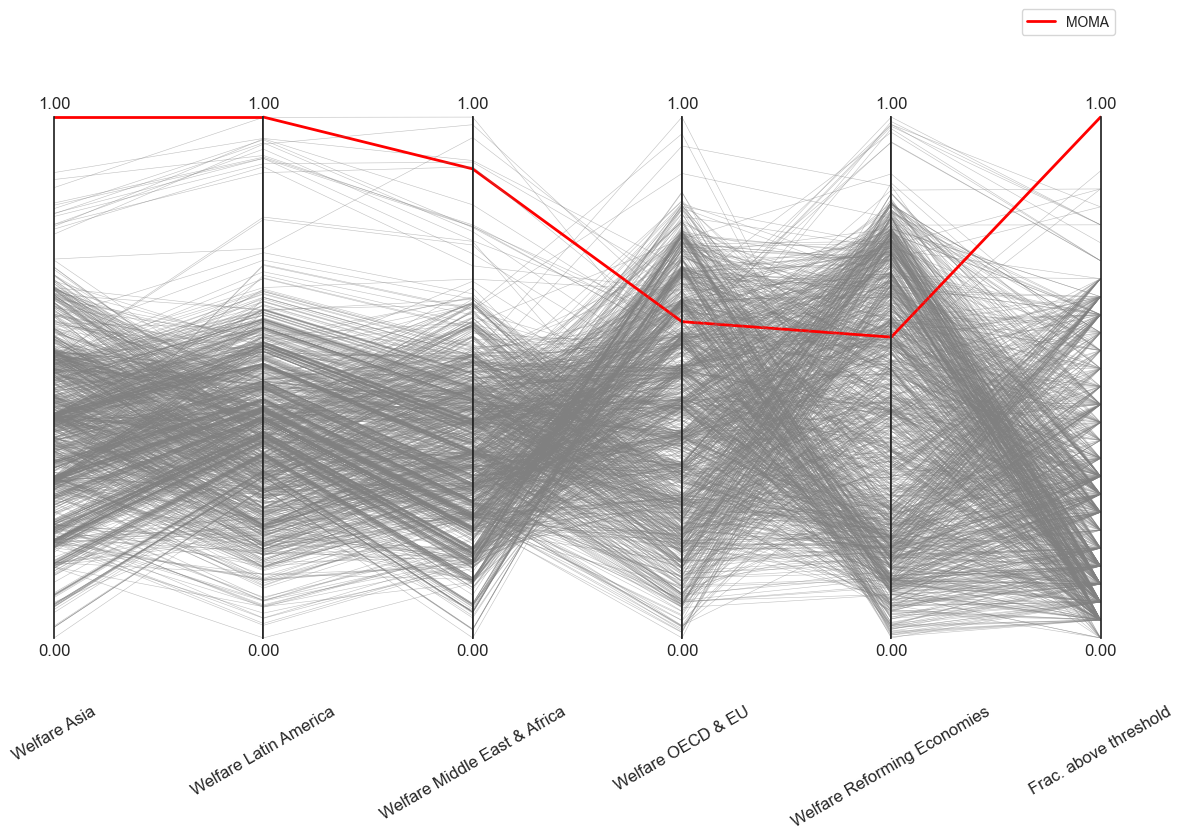

,macro_welfare_R5ASIA,macro_welfare_R5LAM,macro_welfare_R5MAF,macro_welfare_R5OECD,macro_welfare_R5REF,fraction_above_threshold,type
0,0.497533,0.611335,0.480264,0.136481,0.560413,0.448276,MOMA_combined_reference_set_9_islands.csv
1,0.188449,0.376775,0.145083,0.435351,0.582020,0.034483,MOMA_combined_reference_set_9_islands.csv
2,0.476277,0.561969,0.409347,0.210469,0.162190,0.310345,MOMA_combined_reference_set_9_islands.csv
3,0.336644,0.457149,0.258129,0.033420,0.416562,0.034483,MOMA_combined_reference_set_9_islands.csv
4,0.508205,0.612227,0.481523,0.136490,0.488199,0.413793,MOMA_combined_reference_set_9_islands.csv
...,...,...,...,...,...,...,...
1275,0.331627,0.454610,0.254642,0.023484,0.583586,0.068966,MOMA_combined_reference_set_9_islands.csv
1276,0.309245,0.443707,0.239237,0.011131,0.774387,0.103448,MOMA_combined_reference_set_9_islands.csv
1277,0.266856,0.420926,0.208431,0.486323,0.052264,0.137931,MOMA_combined_reference_set_9_islands.csv
1278,0.293618,0.456969,0.260578,0.433722,0.569373,0.241379,MOMA_combined_reference_set_9_islands.csv


In [ ]:
from justice.util.visualizer import visualize_tradeoffs

"""
R5ASIA  # Asia (R5)
R5LAM   # Latin America (R5)
R5MAF   # Middle East & Africa (R5)
R5OECD  # OECD & EU (R5)
R5REF   # Reforming Economies (R5)
"""

filename = "MOMA_combined_reference_set_9_islands.csv"#"MOMA_reference_set.csv" #"MOMA_combined_reference_set_9_islands.csv" #"MOMA_reference_set.csv" #"MOMA_reference_set_SORTED.csv" #"MOMA_combined_reference_set_9_islands.csv"
# filename = "200000.csv"

visualize_tradeoffs(
    input_data=[filename],
    figsize=(12, 8),
    set_style="whitegrid",
    font_scale=1.8,
    colourmap="bright",
    linewidth=0.4,
    alpha=0.5,
    path_to_data="data/temporary/MOMA_DATA/200k/",
    path_to_output="data/temporary/MOMA_DATA/200k",
    scaling=True,
    feature_range=(0, 1),
    column_labels=None,
    legend_labels=None,
    show_legend=True,
    axis_rotation=30,
    fontsize=12,
    list_of_objectives=[
        "macro_welfare_R5ASIA",
        "macro_welfare_R5LAM",
        "macro_welfare_R5MAF",
        "macro_welfare_R5OECD",
        "macro_welfare_R5REF",
        "fraction_above_threshold",
    ],
    direction_of_optimization=[
        "max",
        "max",
        "max",
        "max",
        "max",
        "min",
    ],
    pretty_labels=[

        "Welfare Asia", #R5ASIA
        "Welfare Latin America", #R5LAM
        "Welfare Middle East & Africa", #R5MAF
        "Welfare OECD & EU", #R5OECD
        "Welfare Reforming Economies", #R5REF
        "Frac. above threshold",
    ],
    default_colors=["red", "blue"],
    top_percentage=0.1,
    show_best_solutions=True,
    highlight_indices={filename: [1230]},  # ← new: list of row‐indices you want to highlight
    highlight_factor=5,  # ← new: how many× thicker for highlighted rows
    # temperature_filter=False,
    saving=False,
)








#### Computing Hypervolume

In [ ]:
## This block computes the Hypervolume for the reference set

filenames = [


    # Loading Archives for the different seeds  Borg
    f"MOMA_{nfe}_ref{ssp_ref}_{seed}_0.tar.gz", 
    f"MOMA_{nfe}_ref{ssp_ref}_{seed}_1.tar.gz",
    f"MOMA_{nfe}_ref{ssp_ref}_{seed}_2.tar.gz",
    f"MOMA_{nfe}_ref{ssp_ref}_{seed}_3.tar.gz",
    f"MOMA_{nfe}_ref{ssp_ref}_{seed}_4.tar.gz",
]

reference_set = "MOMA_reference_set.csv"
# reference_set =  "200000.csv"

with multiprocessing.Pool() as pool:
    # Enumerate through the filenames
    for filename in filenames:
        scores = calculate_hypervolume_from_archives(
            list_of_objectives=list_of_objectives,
            direction_of_optimization=direction_of_optimization,
            input_data_path=data_path,
            file_name=filename,
            output_data_path=path + "/hypervolumes/",
            saving=True,
            global_reference_set=True,
            global_reference_set_path=path,
            global_reference_set_file=reference_set,
            pool=pool,
          )  # NOTE: Change this according to the PF refset
        



python(80652) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(80653) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(80654) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(80655) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(80656) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(80657) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(80658) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(80659) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(80660) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(80661) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Loading archives for MOMA_200000_ref2_555_0.tar.gz
Archives loaded
list_of_archives:  (6243, 6)
reference_set (264, 6)
type of reference_set <class 'numpy.ndarray'>
nfes: 
 [100, 10000, 100000, 105000, 110000, 115000, 120000, 125000, 130000, 135000, 140000, 145000, 15000, 150000, 155000, 160000, 165000, 170000, 175000, 180000, 185000, 190000, 195000, 20000, 200000, 25000, 30000, 35000, 40000, 45000, 5000, 50000, 55000, 60000, 65000, 70000, 75000, 80000, 85000, 90000, 95000]
Computing hypervolume for  MOMA_200000_ref2_555_0.tar.gz
Time taken for Hypervolume Calculation: 3.189 seconds
data/temporary/MOMA_DATA/200k/hypervolumes//MOMA_200000_ref2_555_0_hv.csv
Loading archives for MOMA_200000_ref2_555_1.tar.gz
Archives loaded
list_of_archives:  (5029, 6)
reference_set (264, 6)
type of reference_set <class 'numpy.ndarray'>
nfes: 
 [100, 10000, 100000, 105000, 110000, 115000, 120000, 125000, 130000, 135000, 140000, 145000, 15000, 150000, 155000, 160000, 165000, 170000, 175000, 180000, 185000,

In [3]:
input_data_path_list = {
    
   "MOMA": [
    f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_0_hv.csv", 
    f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_1_hv.csv",
    f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_2_hv.csv",
    f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_3_hv.csv",
    f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_4_hv.csv",
    ],
}


fig = plot_hypervolume(
    path_to_data=path,
    path_to_output=path,
    input_data=input_data_path_list,
    yaxis_upper_limit=0.3,
    width=1000,
    height=800,
    fontsize=20,
    saving=True,
)

fig.show()

FileNotFoundError: [Errno 2] No such file or directory: 'data/temporary/MOMA_DATA/200k/hypervolumes/MOMA_200000_ref2_555_0_hv.csv'

## Testing

In [1]:
import json
import numpy as np
from pathlib import Path

from ema_workbench import Constant
from justice.util.EMA_model_wrapper import model_wrapper_momadps, _compute_inverse_range

from justice.util.regional_configuration import aggregate_by_macro_region, build_macro_region_mapping
from justice.util.data_loader import DataLoader
from justice.util.enumerations import *
from justice.util.model_time import TimeHorizon
from solvers.emodps.rbf import RBF

def smoke_test_momadps(config_path, mapping_base_path="data/input", seed=42):
    rng = np.random.default_rng(seed)

    with open(config_path, "r", encoding="utf-8") as file:
        config = json.load(file)

    start_year = config["start_year"]
    end_year = config["end_year"]
    data_timestep = config["data_timestep"]
    timestep = config["timestep"]
    emission_control_start_year = config["emission_control_start_year"]
    n_inputs = config["n_inputs"]
    temperature_year_of_interest = config["temperature_year_of_interest"]
    stochastic_run = config["stochastic_run"]
    climate_members = config.get("climate_ensemble_members")

    min_temperature = config["min_temperature"]
    max_temperature = config["max_temperature"]
    min_temperature_change = config["min_temperature_change"]
    max_temperature_change = config["max_temperature_change"]
    consumption_min = config["consumption_min"]
    consumption_max = config["consumption_max"]

    data_loader = DataLoader()
    region_list = data_loader.REGION_LIST
    n_regions = len(region_list)

    time_horizon = TimeHorizon(
        start_year=start_year,
        end_year=end_year,
        data_timestep=data_timestep,
        timestep=timestep,
    )
    emission_start_ts = time_horizon.year_to_timestep(
        year=emission_control_start_year, timestep=timestep
    )
    temperature_year_index = time_horizon.year_to_timestep(
        year=temperature_year_of_interest, timestep=timestep
    )
    n_timesteps = len(time_horizon.model_time_horizon)

    r5_json = Path(mapping_base_path) / "R5_regions.json"
    rice50_json = Path(mapping_base_path) / "rice50_regions_dict.json"
    region_to_macro, macro_region_names = build_macro_region_mapping(
        region_list=region_list,
        r5_json_path=r5_json,
        rice50_json_path=rice50_json,
    )
    n_macro_regions = len(macro_region_names)

    # Derive RBF shapes
    rbf_template = RBF(
        n_rbfs=(n_inputs + 2),
        n_inputs=n_inputs,
        n_outputs=1,
    )
    centers_shape, radii_shape, weights_shape = rbf_template.get_shape()
    centers_len, radii_len, weights_len = (
        centers_shape[0],
        radii_shape[0],
        weights_shape[0],
    )

    # Build kwargs dictionary with random RBF parameters
    kwargs = {
        "ssp_rcp_scenario": rng.integers(0, 8),
        "social_welfare_function_type": WelfareFunction.from_index(0).value[0],
        "economy_type": Economy.NEOCLASSICAL.value,
        "damage_function_type": DamageFunction.KALKUHL.value,
        "abatement_type": Abatement.ENERDATA.value,
        "stochastic_run": stochastic_run,
        "n_regions": n_regions,
        "n_timesteps": n_timesteps,
        "emission_control_start_timestep": emission_start_ts,
        "n_inputs_rbf": n_inputs,
        "n_outputs_rbf": 1,
        "temperature_year_of_interest_index": temperature_year_index,
        "climate_ensemble_members": climate_members,
        "min_temperature": min_temperature,
        "max_temperature": max_temperature,
        "min_temperature_change": min_temperature_change,
        "max_temperature_change": max_temperature_change,
        "consumption_min": consumption_min,
        "consumption_max": consumption_max,
        "region_to_macro": region_to_macro.tolist(),
        "macro_region_names": list(macro_region_names),
        "n_macro_regions": n_macro_regions,
    }

    for macro_idx in range(n_macro_regions):
        kwargs.update(
            {
                f"center {macro_idx} {i}": rng.uniform(-1.0, 1.0)
                for i in range(centers_len)
            }
        )
        kwargs.update(
            {
                f"radii {macro_idx} {i}": rng.uniform(1e-4, 1.0)
                for i in range(radii_len)
            }
        )
        kwargs.update(
            {
                f"weights {macro_idx} {i}": rng.uniform(1e-4, 1.0)
                for i in range(weights_len)
            }
        )

    # Run the wrapper once with random levers
    results = model_wrapper_momadps(**kwargs)
    print("Wrapper objectives:", results)


if __name__ == "__main__":
    smoke_test_momadps("analysis/momadps_config.json")

/Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[[ 4.59727738  4.59727738  4.59727738  4.59727738  4.59727738  4.59727738
   4.59727738  4.59727738  4.59727738  4.59727738  4.59727738  4.59727738
   4.59727738  4.59727738  4.59727738  4.59727738  4.59727738  4.59727738
   4.59727738  4.59727738  4.59727738  4.59727738  4.59727738  4.59727738
   4.59727738  4.59727738  4.59727738  4.59727738  4.59727738  4.59727738
   4.59727738  4.59727738  4.59727738  4.59727738  4.59727738  4.59727738
   4.59727738  4.59727738  4.59727738  4.59727738  4.59727738  4.59727738
   4.59727738  4.59727738  4.59727738  4.59727738  4.59727738  4.59727738
   4.59727738  4.59727738]
 [ 9.86689535  9.86689535  9.86689535  9.86689535  9.86689535  9.86689535
   9.86689535  9.86689535  9.86689535  9.86689535  9.86689535  9.86689535
   9.86689535  9.86689535  9.86689535  9.86689535  9.86689535  9.86689535
   9.86689535  9.86689535  9.86689535  9.86689535  9.86689535  9.86689535
   9.86689535  9.86689535  9.86689535  9.86689535  9.86689535  9.86689535
   9.866895

In [10]:
df.columns

Index(['center 0 0', 'center 0 1', 'center 0 2', 'center 0 3', 'center 0 4',
       'center 0 5', 'center 0 6', 'center 0 7', 'center 0 8', 'center 0 9',
       ...
       'weights 4 1', 'weights 4 2', 'weights 4 3', 'weights 4 4',
       'macro_welfare_R5ASIA', 'macro_welfare_R5LAM', 'macro_welfare_R5MAF',
       'macro_welfare_R5OECD', 'macro_welfare_R5REF',
       'fraction_above_threshold'],
      dtype='object', length=181)

# Simulating with Optimal policies

In [ ]:
#TODO need to update CPC calculation like the momadps wrapper

import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple, Dict, Any, Optional

from justice.util.enumerations import Economy, DamageFunction, Abatement, WelfareFunction, Scenario
from justice.model import JUSTICE
from justice.util.emission_control_constraint import EmissionControlConstraint
from solvers.emodps.rbf import RBF
from justice.util.regional_configuration import aggregate_by_macro_region
from justice.objectives.objective_functions import fraction_of_ensemble_above_threshold

from justice.util.regional_configuration import build_macro_region_mapping



from justice.util.data_loader import DataLoader

from justice.util.model_time import TimeHorizon


def run_momadps_policy(
    policy_csv_path: str,
    policy_index: int,
    scenario: int = 2,
    config_path: str = "momadps_config.json",
    mapping_base_path: str = "data/input",
) -> Tuple[Tuple[float, ...], Dict[str, np.ndarray]]:
    """
    Re-simulate JUSTICE under a multi-agent RBF policy taken from a CSV row.

    Parameters
    ----------
    policy_csv_path : str
        Path to the CSV file containing optimization results (centers/radii/weights/metrics).
    policy_index : int
        Row index to extract. Supports negative indices (like pandas .iloc).
    scenario : Scenario
        Which SSP-RCP scenario to run (default: SSP2-RCP45).
    config_path : str
        JSON config used during MOMADPS optimization (e.g., "momadps_config.json").
    mapping_base_path : str
        Directory containing "R5_regions.json" and "rice50_regions_dict.json".

    Returns
    -------
    objectives : Tuple[float, ...]
        A 6-tuple (five macro welfare metrics + fraction-above-threshold) matching the wrapper outputs.
    datasets : Dict[str, np.ndarray]
        Full JUSTICE datasets dictionary; includes a "constrained_emission_control_rate" array.
    """

    # --- Load config & policy row --------------------------------------------------
    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)

    df = pd.read_csv(policy_csv_path)
    if policy_index < -len(df) or policy_index >= len(df):
        raise IndexError(
            f"policy_index {policy_index} out of bounds for CSV with {len(df)} rows."
        )
    policy_row = df.iloc[int(policy_index)]

    # --- Extract shared settings (mirrors analyzer setup) --------------------------
    start_year = config["start_year"]
    end_year = config["end_year"]
    data_timestep = config["data_timestep"]
    timestep = config["timestep"]
    emission_control_start_year = config["emission_control_start_year"]

    n_inputs = config["n_inputs"]
    temperature_year_of_interest = config["temperature_year_of_interest"]
    stochastic_run = config["stochastic_run"]
    climate_members = config.get("climate_ensemble_members")

    min_temperature = config["min_temperature"]
    max_temperature = config["max_temperature"]
    min_temperature_change = config["min_temperature_change"]
    max_temperature_change = config["max_temperature_change"]
    consumption_min = config["consumption_min"]
    consumption_max = config["consumption_max"]

    data_loader = DataLoader()
    region_list = data_loader.REGION_LIST
    n_regions = len(region_list)

    time_horizon = TimeHorizon(
        start_year=start_year,
        end_year=end_year,
        data_timestep=data_timestep,
        timestep=timestep,
    )
    emission_start_ts = time_horizon.year_to_timestep(
        year=emission_control_start_year, timestep=timestep
    )
    temperature_year_index = time_horizon.year_to_timestep(
        year=temperature_year_of_interest, timestep=timestep
    )
    n_timesteps = len(time_horizon.model_time_horizon)

    r5_json = Path(mapping_base_path) / "R5_regions.json"
    rice50_json = Path(mapping_base_path) / "rice50_regions_dict.json"
    region_to_macro, macro_region_names = build_macro_region_mapping(
        region_list=region_list,
        r5_json_path=r5_json,
        rice50_json_path=rice50_json,
    )
    n_macro_regions = len(macro_region_names)

    macro_region_counts = np.bincount(region_to_macro, minlength=n_macro_regions).astype(float)
    macro_region_counts = macro_region_counts[:, None]  # (n_macro, 1)

    # --- Construct RBFs exactly as in optimization ---------------------------------
    rbf_template = RBF(
        n_rbfs=(n_inputs + 2),
        n_inputs=n_inputs,
        n_outputs=1,
    )
    centers_shape, radii_shape, weights_shape = rbf_template.get_shape()
    centers_len, radii_len, weights_len = (
        centers_shape[0],
        radii_shape[0],
        weights_shape[0],
    )

    macro_rbfs = []
    for macro_idx in range(n_macro_regions):
        centers = np.array(
            [policy_row[f"center {macro_idx} {i}"] for i in range(centers_len)]
        )
        radii = np.array(
            [policy_row[f"radii {macro_idx} {i}"] for i in range(radii_len)]
        )
        weights = np.array(
            [policy_row[f"weights {macro_idx} {i}"] for i in range(weights_len)]
        )

        rbf = RBF(
            n_rbfs=(n_inputs + 2),
            n_inputs=n_inputs,
            n_outputs=1,
        )
        decision_vars = np.concatenate((centers, radii, weights))
        rbf.set_decision_vars(decision_vars)
        macro_rbfs.append(rbf)

    # --- Instantiate JUSTICE -------------------------------------------------------
    model = JUSTICE(
        scenario=scenario,
        economy_type=Economy.NEOCLASSICAL,
        damage_function_type=DamageFunction.KALKUHL,
        abatement_type=Abatement.ENERDATA,
        social_welfare_function=WelfareFunction.UTILITARIAN,
        stochastic_run=stochastic_run,
        # climate_ensembles=climate_members,
    )

    no_of_ensembles = model.__getattribute__("no_of_ensembles")

    emission_constraint = EmissionControlConstraint(
        max_annual_growth_rate=0.04,
        emission_control_start_timestep=emission_start_ts,
        min_emission_control_rate=0.01,
    )

    inv_temperature_range = 1.0 / (max_temperature - min_temperature)
    inv_temperature_change_range = 1.0 / (max_temperature_change - min_temperature_change)
    inv_consumption_range = 1.0 / (consumption_max - consumption_min)

    regional_emission_control_rate = np.zeros(
        (n_regions, n_timesteps, no_of_ensembles), dtype=float
    )
    constrained_emission_control_rate = np.zeros_like(regional_emission_control_rate)
    macro_emission_control_rate = np.zeros(
        (n_macro_regions, n_timesteps, no_of_ensembles), dtype=float
    )
    macro_consumption_history = np.zeros(
        (n_macro_regions, n_timesteps, no_of_ensembles), dtype=float
    )

    rbf_input_buffer = np.empty((n_inputs, no_of_ensembles), dtype=float)
    previous_temperature = np.zeros(no_of_ensembles, dtype=float)
    previous_temperature_change = np.zeros(no_of_ensembles, dtype=float)


    region_population = model.economy.get_population()  # shape: (n_regions, n_timesteps, no_of_ensembles)
    # --- Simulation loop -----------------------------------------------------------
    for timestep in range(n_timesteps):
        constrained_emission_control_rate[:, timestep, :] = (
            emission_constraint.constrain_emission_control_rate(
                regional_emission_control_rate[:, timestep, :],
                timestep,
                allow_fallback=False,
            )
        )

        model.stepwise_run(
            emission_control_rate=constrained_emission_control_rate[:, timestep, :],
            timestep=timestep,
            endogenous_savings_rate=True,
        )
        datasets = model.stepwise_evaluate(timestep=timestep)

        global_temperature = datasets["global_temperature"][timestep, :]
        consumption = datasets["consumption"][:, timestep, :]  # (n_regions, no_of_ensembles)
        # consumption_per_capita = datasets["consumption_per_capita"][:, timestep, :]

        if timestep == 0:
            temperature_change = np.zeros_like(global_temperature)
            previous_temperature = global_temperature.copy()
            previous_temperature_change = temperature_change.copy()
        elif timestep % 5 == 0:
            temperature_change = global_temperature - previous_temperature
            previous_temperature = global_temperature.copy()
            previous_temperature_change = temperature_change.copy()
        else:
            temperature_change = previous_temperature_change

        rbf_input_buffer[0, :] = np.clip(
            (global_temperature - min_temperature) * inv_temperature_range,
            0.0,
            1.0,
        )
        rbf_input_buffer[1, :] = np.clip(
            (temperature_change - min_temperature_change)
            * inv_temperature_change_range,
            0.0,
            1.0,
        )

        # --- population-weighted macro per-capita -----------------------------
        pop_t = region_population[:, timestep, :]                       # (n_regions, no_of_ensembles)
        macro_population = aggregate_by_macro_region(pop_t, region_to_macro)          # (n_macro_regions, no_of_ensembles)
        macro_total_consumption = aggregate_by_macro_region(consumption, region_to_macro)  # (n_macro_regions, no_of_ensembles)
        macro_cpc = (macro_total_consumption / macro_population)*1e3  # population-weighted per-capita
        macro_consumption_history[:, timestep, :] = macro_cpc



        # aggregated_consumption = aggregate_by_macro_region(
        #     consumption_per_capita, region_to_macro
        # )
        # macro_mean_consumption = aggregated_consumption / macro_region_counts
        # macro_consumption_history[:, timestep, :] = macro_mean_consumption





        normalized_macro_consumption = np.clip(
            (macro_cpc - consumption_min) * inv_consumption_range,
            0.0,
            1.0,
        )

        if timestep < n_timesteps - 1:
            for macro_idx, rbf in enumerate(macro_rbfs):
                rbf_input_buffer[2, :] = normalized_macro_consumption[macro_idx, :]
                macro_output = rbf.apply_rbfs(rbf_input_buffer)
                macro_emission_control_rate[macro_idx, timestep + 1, :] = macro_output

            regional_emission_control_rate[:, timestep + 1, :] = macro_emission_control_rate[
                region_to_macro, timestep + 1, :
            ]

    datasets = model.evaluate()
    datasets["constrained_emission_control_rate"] = constrained_emission_control_rate
    datasets["macro_consumption_history"] = macro_consumption_history
    datasets["regional_emission_control_rate"] = regional_emission_control_rate

    spatially_disaggregated_welfare = (
        model.welfare_function.calculate_spatially_disaggregated_welfare(
            macro_consumption_history
        )
    )

    fraction_above_threshold = fraction_of_ensemble_above_threshold(
        temperature=datasets["global_temperature"],
        temperature_year_index=temperature_year_index,
        threshold=2.0,
    )

    objectives = (
        float(spatially_disaggregated_welfare[0]),
        float(spatially_disaggregated_welfare[1]),
        float(spatially_disaggregated_welfare[2]),
        float(spatially_disaggregated_welfare[3]),
        float(spatially_disaggregated_welfare[4]),
        float(fraction_above_threshold),
    )

    model.hard_reset()
    return objectives, datasets




# Usage
objectives, datasets = run_momadps_policy(
    policy_csv_path="data/temporary/MOMA_DATA/200k/MOMA_reference_set.csv", #MOMA_reference_set
    policy_index=26,  # or any row index
    scenario=2,
    config_path="analysis/momadps_config.json",
    mapping_base_path="data/input",
)

print("Objectives:", objectives)
control = datasets["constrained_emission_control_rate"]
print("Control shape:", control.shape)

emissions = datasets["emissions"]

# Save constrained emission control rates to npy file
np.save("data/temporary/MOMA_DATA/200k/constrained_emission_control_rate.npy", control)
np.save("data/temporary/MOMA_DATA/200k/emissions.npy", emissions)

temperature = datasets["global_temperature"]
np.save("data/temporary/MOMA_DATA/200k/global_temperature.npy", temperature)

/Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



Objectives: (1707.7826177768275, 3028.5316193114313, 2138.654016171372, 3373.756691052898, 2145.745056343045, 0.4985014985014985)
Control shape: (57, 286, 1001)


In [8]:
from justice.util.visualizer import plot_comparison_with_boxplots

plot_comparison_with_boxplots(
    data_paths=[
        "data/temporary/MOMA_DATA/200k/global_temperature.npy",
  
    ],
    labels=[
        'MOMA', 
        # 'Prioritarian'
        ], #, 'Sufficientarian', 'Egalitarian'
    start_year=2015,
    end_year=2300,
    data_timestep=5,
    timestep=1,
    visualization_start_year=2025,
    visualization_end_year=2100,
    yaxis_range=[0.5, 5],
    plot_title=' ',
    xaxis_title='Year',
    yaxis_title='Global Temperature (°C)',
    template='plotly_white',
    width=1000,
    height=700,
    output_path="./data/plots/only_welfare_temp",
    saving=False,
    show_red_dashed_line=False,
    show_interquartile_range=True,
    linecolors=[
        "rgba(252, 141, 98, 1)",
        # "rgba(141, 160, 203, 1)",
        ],
    colors = [ 

        "rgba(252, 141, 98, 0.2)",
        # "rgba(141, 160, 203, 0.2)",
        ],
    first_plot_proportion=[0, 0.8],
    second_plot_proportion=[0.90, 1],
    transpose_data=True,
)

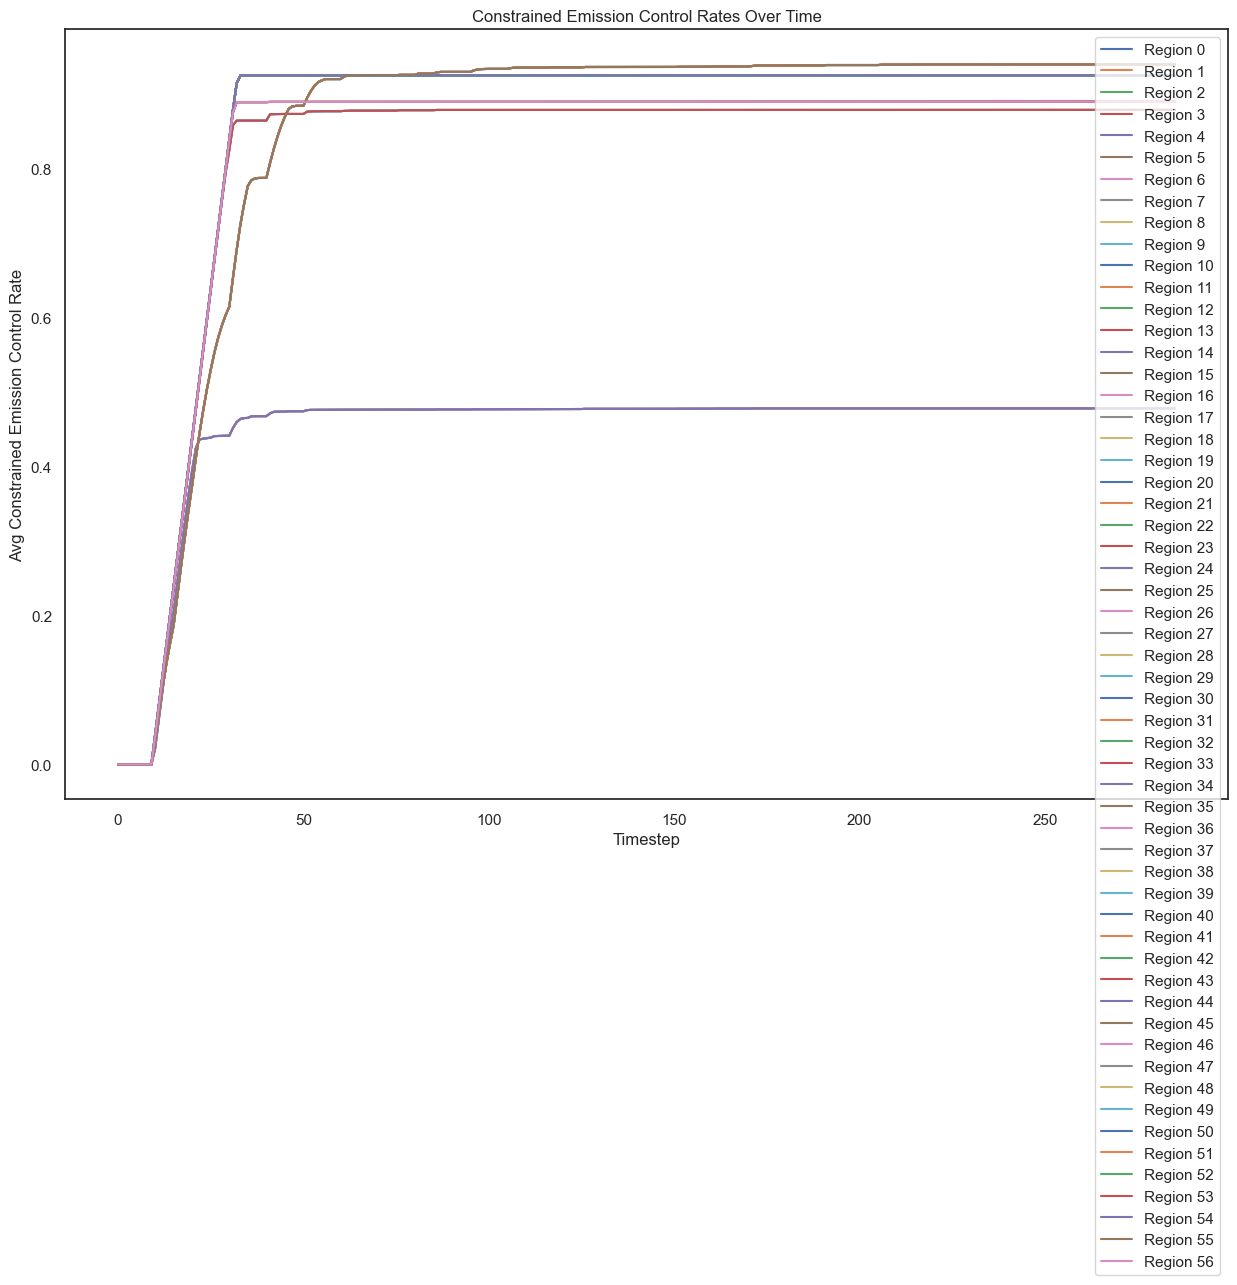

In [20]:
# Plot the constrained emission control rates for the each region over time and taking average over ensembles
import matplotlib.pyplot as plt
avg_control = np.mean(control, axis=2)  # Average over ensembles
n_regions, n_timesteps = avg_control.shape
plt.figure(figsize=(15, 10))
for region_idx in range(n_regions):
    plt.plot(avg_control[region_idx, :], label=f"Region {region_idx}")
plt.xlabel("Timestep")
plt.ylabel("Avg Constrained Emission Control Rate")
plt.title("Constrained Emission Control Rates Over Time")
plt.legend()
plt.show()



In [9]:
# Example usage
# from src.util.visualizer import plot_stacked_area_chart
import json
import plotly.express as px
from justice.util.data_loader import DataLoader
from justice.util.model_time import TimeHorizon
import numpy as np
import pandas as pd
import pickle
from justice.util.regional_configuration import (
    justice_region_aggregator,
)
from justice.util.visualizer import plot_stacked_area_chart_with_baseline_emissions
import os




region_dict = json.load(open('data/input/R5_regions.json'))

fig, prior_data, abated_emissions = plot_stacked_area_chart_with_baseline_emissions(
    variable_name="emissions",
    filetype=".npy",
    path_to_data="data/temporary/MOMA_DATA/200k",
    baseline_emissions_path="data/temporary/MOMA_DATA/200k/baseline_emissions_16.npy",
    #NOTE Change these
    input_data= ["MOMA"],#, "Prioritarian_idx196"],
    output_titles=["MOMA"],#, "Prioritarian"], 
    scenario_list=['SSP245'], 
    title=" ",
    xaxis_label="Year" ,
    yaxis_label= "", #"Trillion USD (2005 PPP)",
    height=800,
    width=1400,
    visualization_start_year=2025,
    visualization_end_year=2100,
    plot_title=" ",
    groupnorm= 'percent', #'percent',
    # colour_palette=px.colors.qualitative.Set1_r,
    colour_palette = [
        
        'rgb(153,153,153, 0.2)', 'rgb(153,153,153)',  # Grey
        'rgb(247,129,191, 0.2)', 'rgb(247,129,191)', 
        'rgb(166,86,40, 0.2)', 'rgb(166,86,40)', 
        'rgb(55,126,184, 0.2)', 'rgb(55,126,184)', 
        'rgb(255,127,0, 0.2)', 'rgb(255,127,0)'

                      
                      ],
   
    region_dict=region_dict,

    saving=True,
    yaxis_lower_limit=0,
    yaxis_upper_limit=100, #190 damages # 25 abatecost
    # TODO: Need to convert to RICE50_Region_Names with this list
    # Reversed Order
    regional_order = [
        "R5ASIA",
        "R5ASIA_abated",
        "R5LAM",
        "R5LAM_abated",
        "R5MAF",
        "R5MAF_abated",
        "R5OECD",
        "R5OECD_abated",
        "R5REF",
        "R5REF_abated",

    ],
)

fig.show()

# ['Rest of the World', 'Europe', 'Latin America',  'Africa', 'Gulf Countries', 'China', 'India', 'United States']

Loading data for:  SSP245  -  MOMA
Baseline emissions shape:  (57, 286, 1001)
Data shape:  (57, 286, 1001)
Region list:  ['R5LAM', 'R5MAF', 'R5OECD', 'R5ASIA', 'R5REF']
Saving plot for:  SSP245  -  emissions_MOMA_SSP245  at  ./data/plots


In [24]:
import numpy as np
import plotly.express as px

import pandas as pd

from justice.util.visualizer import plot_choropleth_2D_data

path = "data/temporary/MOMA_DATA/200k/"
fig, prior_data = plot_choropleth_2D_data(
    path_to_data=path,
    path_to_output=path, #/rbf_dist_test
    projection= "natural earth1", 
    colourmap= px.colors.sequential.Reds,
    year_to_visualize=2050,
    input_data_path_list=[



        "constrained_emission_control_rate.npy",
       


    ],
        
    data_label="Emission Control Rate",
    legend_label="", 
    data_normalization=True,
    saving=True,
    show_colorbar=True,
    normalized_colorbar=True,

)

fig.show()



Taking average over the last dimension.
0


In [38]:
import pandas as pd
# Read csv file into DataFrame


path =  "data/temporary/MOMA_DATA/200k/BORG_SORTED" # Change this to your path
df_1 = pd.read_csv(f"{path}/200000.csv")
df_2 = pd.read_csv(f"{path}/200000 2.csv")

# Concatenate DataFrames
df = pd.concat([df_1, df_2], ignore_index=True)

# Save the combined DataFrame to a new CSV file
df.to_csv(f"{path}/MOMA_combined_reference_set_9_islands.csv", index=False)


# Single Agent HV test

In [ ]:
# This code creates a reference set from the different seeds

# NOTE: For MMBorg archives, run the script to convert it to the format recognized by older code with ema-workbench.
# Example 
# python justice/util/borg_archive_processor.py     --archive /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/MOMA_DATA/200k/AGENT_0/mm_intermediate.zip     --base-name MOMA_200000_ref2_555     --step 10000

from solvers.convergence.hypervolume import get_global_reference_set, calculate_hypervolume_from_archives
import multiprocessing
# Suppress warnings
import warnings

from justice.util.enumerations import WelfareFunction, SSP
from justice.util.visualizer import plot_hypervolume

AGENT = 0

warnings.filterwarnings("ignore")

base_path = f"data/temporary/MOMA_DATA/200k/AGENT_{AGENT}" # Change this to your path

swf = WelfareFunction.UTILITARIAN
nfe = 200_000
ssp = SSP.SSP2
ssp_ref = 2
seed = 555
path = f"{base_path}/"
welfare_epsilon = 0.01


print(f"Loading data from {path}...")

list_of_objectives = [
    "macro_welfare_R5ASIA",
    "macro_welfare_R5LAM",
    "macro_welfare_R5MAF",
    "macro_welfare_R5OECD",
    "macro_welfare_R5REF",
    "fraction_above_threshold",
]
objectives = [list_of_objectives[AGENT], "fraction_above_threshold"]
data_path = path 

direction_of_optimization = ["max", "min"] #, "max", "max"

get_global_reference_set(
    list_of_objectives=objectives,
    data_path=data_path,
    #file_name=None,
    swf="MOMA",
    nfe=str(nfe), # Ran for 50k number of function evaluations

    # Setting the same epsilon values as optimization process  (see analysis/analyzer.py)
    epsilons=[welfare_epsilon,  0.01],


    direction_of_optimization=direction_of_optimization,
    output_data_path=path,
    saving=True,
)




Loading data from data/temporary/MOMA_DATA/200k/AGENT_0/...
Loading list of files
Loading archives for:  MOMA
Filename:  .DS_Store
Filename:  mm_intermediate.zip
Filename:  MOMA_reference_set.csv
Filename:  MOMA_200000_ref2_555_2.tar.gz
Matching file: MOMA_200000_ref2_555_2.tar.gz
Loading archives from: MOMA_200000_ref2_555_2.tar.gz
Max key: 200000
Number of rows in archive: 24
Archives loaded for: MOMA_200000_ref2_555_2.tar.gz
Filename:  MOMA_200000_ref2_555_0.tar.gz
Matching file: MOMA_200000_ref2_555_0.tar.gz
Loading archives from: MOMA_200000_ref2_555_0.tar.gz
Max key: 200000
Number of rows in archive: 24
Archives loaded for: MOMA_200000_ref2_555_0.tar.gz
Filename:  hypervolumes
Filename:  MOMA_200000_ref2_555_3.tar.gz
Matching file: MOMA_200000_ref2_555_3.tar.gz
Loading archives from: MOMA_200000_ref2_555_3.tar.gz
Max key: 200000
Number of rows in archive: 24
Archives loaded for: MOMA_200000_ref2_555_3.tar.gz
Filename:  Moma_hypervolume_plot.svg
Filename:  MOMA_200000_ref2_555_1.t

{'MOMA':     center 0 0  center 0 1  center 0 2  center 0 3  center 0 4  center 0 5  \
 14    0.315678    -0.82602    0.263472   -0.984424     -0.0137    0.991636   
 
     center 0 6  center 0 7  center 0 8  center 0 9  ...  radii 0 12  \
 14    0.303107   -0.886593    0.204188    0.900489  ...    0.978083   
 
     radii 0 13  radii 0 14   weights 0 0   weights 0 1   weights 0 2  \
 14    0.025952     0.94842  1.000000e-09  1.000000e-09  1.000000e-09   
 
     weights 0 3   weights 0 4  macro_welfare_R5ASIA  fraction_above_threshold  
 14     0.993581  1.000000e-09           1703.287978                      0.42  
 
 [1 rows x 37 columns]}

In [7]:
## This block computes the Hypervolume for the reference set

filenames = [


    # Loading Archives for the different seeds  Borg
    f"MOMA_{nfe}_ref{ssp_ref}_{seed}_0.tar.gz", 
    f"MOMA_{nfe}_ref{ssp_ref}_{seed}_1.tar.gz",
    f"MOMA_{nfe}_ref{ssp_ref}_{seed}_2.tar.gz",
    f"MOMA_{nfe}_ref{ssp_ref}_{seed}_3.tar.gz",
    # f"MOMA_{nfe}_ref{ssp_ref}_{seed}_4.tar.gz",
]

# reference_set = "MOMA_reference_set.csv"
reference_set =  "200000.csv"

with multiprocessing.Pool() as pool:
    # Enumerate through the filenames
    for filename in filenames:
        scores = calculate_hypervolume_from_archives(
            list_of_objectives=list_of_objectives,
            direction_of_optimization=direction_of_optimization,
            input_data_path=data_path,
            file_name=filename,
            output_data_path=path + "/hypervolumes/",
            saving=True,
            global_reference_set=True,
            global_reference_set_path=path,
            global_reference_set_file=reference_set,
            pool=pool,
          )  # NOTE: Change this according to the PF refset
        



Loading archives for MOMA_200000_ref2_555_0.tar.gz
Archives loaded
list_of_archives:  (475, 2)
reference_set (24, 2)
type of reference_set <class 'numpy.ndarray'>
nfes: 
 [100, 10000, 100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 20000, 200000, 30000, 40000, 50000, 60000, 70000, 80000, 90000]
Computing hypervolume for  MOMA_200000_ref2_555_0.tar.gz
Time taken for Hypervolume Calculation: 3.077 seconds
data/temporary/MOMA_DATA/200k/AGENT_0//hypervolumes//MOMA_200000_ref2_555_0_hv.csv
Loading archives for MOMA_200000_ref2_555_1.tar.gz
Archives loaded
list_of_archives:  (420, 2)
reference_set (24, 2)
type of reference_set <class 'numpy.ndarray'>
nfes: 
 [100, 10000, 100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 20000, 200000, 30000, 40000, 50000, 60000, 70000, 80000, 90000]
Computing hypervolume for  MOMA_200000_ref2_555_1.tar.gz
Time taken for Hypervolume Calculation: 0.003 seconds
data/temporary/MOMA_DATA/200k/AGENT_0//

In [8]:
input_data_path_list = {
    
   "MOMA": [
    f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_0_hv.csv", 
    f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_1_hv.csv",
    f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_2_hv.csv",
    f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_3_hv.csv",
    # f"hypervolumes/MOMA_{nfe}_ref{ssp_ref}_{seed}_4_hv.csv",
    ],
}


fig = plot_hypervolume(
    path_to_data=path,
    path_to_output=path,
    input_data=input_data_path_list,
    yaxis_upper_limit=1.0,
    width=1000,
    height=800,
    fontsize=20,
    saving=True,
)

fig.show()

In [ ]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Sequence

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _agent_columns(columns: Sequence[str], prefix: str, agent: int) -> list[str]:
    """Return sorted columns matching `<prefix> <agent> <index>`."""
    pattern = re.compile(rf"^{re.escape(prefix)}\s+{agent}\s+(\d+)$")
    matched = [
        (int(match.group(1)), column)
        for column in columns
        if (match := pattern.match(column))
    ]
    matched.sort(key=lambda item: item[0])
    return [column for _, column in matched]


def visualize_agent_hyperparameters(
    filepath: str | Path,
    agent: int,
    row_index: int,
    *,
    colorscale: str = "RdBu",
    show: bool = True,
    fig_title: str | None = None,
    outline_gap: float = 1.0,
    background_color: str = "white",
) -> go.Figure:
    """
    Visualise the center, radii and weights hyperparameters for one agent-row in uniform heatmap boxes.
    """
    path = Path(filepath)
    if not path.is_file():
        raise FileNotFoundError(f"Could not find reference set at {path}")

    df = pd.read_csv(path)

    if not (0 <= row_index < len(df)):
        raise IndexError(
            f"row_index {row_index} is out of bounds (data contains {len(df)} rows)"
        )

    row = df.iloc[row_index]
    hyperparameter_types = ["center", "radii", "weights"]
    columns_per_type = {
        prefix: _agent_columns(df.columns, prefix, agent)
        for prefix in hyperparameter_types
    }

    if any(not cols for cols in columns_per_type.values()):
        missing = [prefix for prefix, cols in columns_per_type.items() if not cols]
        raise ValueError(
            f"No columns found for {', '.join(missing)} (agent {agent})."
        )

    max_columns = max(len(cols) for cols in columns_per_type.values())

    data_for_plotting: list[tuple[str, np.ndarray]] = []
    for prefix in hyperparameter_types:
        cols = columns_per_type[prefix]
        values = pd.to_numeric(row[cols], errors="coerce").to_numpy(dtype=float)

        if prefix == "center":
            values = (values + 1) / 2
            np.clip(values, 0, 1, out=values)

        padded = np.full(max_columns, np.nan, dtype=float)
        padded[: len(values)] = values
        data_for_plotting.append((prefix.capitalize(), padded.reshape(1, -1)))

    fig = make_subplots(
        rows=1,
        cols=len(data_for_plotting),
        shared_yaxes=False,
        horizontal_spacing=0.03,
        subplot_titles=[title for title, _ in data_for_plotting],
        column_widths=[1.0 / len(data_for_plotting)] * len(data_for_plotting),
    )

    for col_id, (title, matrix) in enumerate(data_for_plotting, start=1):
        fig.add_trace(
            go.Heatmap(
                z=matrix,
                colorscale=colorscale,
                zmin=0,
                zmax=1,
                hoverinfo="skip",
                xgap=outline_gap,
                ygap=outline_gap,
                zsmooth=False,
                showscale=(col_id == 1),  # show only on the first heatmap

            ),
            row=1,
            col=col_id,
        )
        fig.update_xaxes(showticklabels=False, row=1, col=col_id, range=[-0.5, max_columns - 0.5])
        fig.update_yaxes(showticklabels=False, row=1, col=col_id)

    fig.update_layout(
        title=fig_title or f"Agent {agent} hyperparameters (row {row_index})",
        height=320,
        width=900,
        margin=dict(t=90, b=20, l=30, r=30),
        template="plotly_white",
        paper_bgcolor=background_color,
        plot_bgcolor=background_color,
    )

    if show:
        fig.show()


    return fig




for agent_id in range(5):
    visualize_agent_hyperparameters(
        filepath="data/temporary/MOMA_DATA/200k/MOMA_combined_reference_set_9_islands.csv",
        agent=agent_id,
        row_index=1230,
        colorscale="plasma",
        outline_gap=1.5,
        show=True,
    )

# visualize_agent_hyperparameters(
#     filepath="data/temporary/MOMA_DATA/200k/MOMA_combined_reference_set_9_islands.csv",
#     agent=0,
#     row_index=1230,
#     colorscale="viridis",
#     outline_gap=1.5,
#     show=False,
# )

In [7]:
from solvers.emodps.rbf import RBF
n_inputs = 3  # Example number of inputs

rbf_probe = RBF(
    n_rbfs=(n_inputs + 2),
    n_inputs=n_inputs,
    n_outputs=1,
)

centers_shape, radii_shape, weights_shape = rbf_probe.get_shape()

print("Centers shape:", centers_shape)
print("Radii shape:", radii_shape)
print("Weights shape:", weights_shape)

Centers shape: (15,)
Radii shape: (15,)
Weights shape: (5,)


In [20]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Sequence

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


def plot_region_choropleth(
    *,
    region_map: str | Path,
    projection: str = "natural earth",
    colourmap: Sequence[str] | None = None,
    path_to_output: str | Path,
    plot_saving_format: str = "svg",
    saving: bool = False,
    fig_title: str | None = None,
    show_legend: bool = True,
    width: int = 1000,
    height: int = 600,
    pretty_region_names: Mapping[str, str] | None = None,
) -> go.Figure:
    """
    Draw a choropleth that colours every region (group of countries) with a single discrete colour.
    """
    path = Path(region_map)
    if not path.is_file():
        raise FileNotFoundError(f"region_map not found: {path}")

    with path.open("r", encoding="utf-8") as fh:
        region_definition = json.load(fh)

    if not isinstance(region_definition, dict):
        raise ValueError("region_map JSON must be an object mapping region names to lists of ISO3 codes.")

    records = []
    for region_name, members in region_definition.items():
        if not isinstance(members, Sequence):
            raise ValueError("Each region entry must map to a sequence of ISO3 country identifiers.")
        for iso_code in members:
            records.append({"region": region_name, "iso_alpha": iso_code})

    if not records:
        raise ValueError("No regions found in the provided JSON map.")

    df = pd.DataFrame.from_records(records)
    df["region"] = df["region"].astype(str)
    df = df[df["iso_alpha"].str.upper() != "ATA"] # Exclude Antarctica

    
    pretty_region_names = pretty_region_names or {}
    df["pretty_region"] = df["region"].map(pretty_region_names).fillna(df["region"])
   
    unique_pretty_labels = df["pretty_region"].unique()
    palette = list(colourmap) if colourmap else px.colors.qualitative.Plotly
    if not palette:
        palette = px.colors.qualitative.Plotly

    color_discrete_map = {
        label: palette[i % len(palette)] for i, label in enumerate(unique_pretty_labels)
    }

    # unique_regions = df["region"].unique()
    # color_discrete_map = {
    #     region: palette[i % len(palette)] for i, region in enumerate(unique_regions)
    # }

    fig = px.choropleth(
        df,
        locations="iso_alpha",
        color="pretty_region",
        color_discrete_map=color_discrete_map,
        projection=projection,
        scope="world",
        height=height,
        width=width,
        title=fig_title or "Region choropleth",
    )

    fig.update_layout(
        margin=dict(l=0, r=0, t=40, b=0),
        template="plotly_white",
        showlegend=show_legend,
    )
    fig.update_traces(
        marker_line_width=0,
        marker_line_color="white",
        hovertemplate="%{location}<extra>%{customdata[0]}</extra>",
        customdata=df[["region"]],
    )

    if saving:
        output_dir = Path(path_to_output)
        output_dir.mkdir(parents=True, exist_ok=True)
        filename = output_dir / f"region_choropleth.{plot_saving_format}"
        fig.write_image(str(filename))

    return fig

pretty_names = {
    "R5ASIA": "Asia",
    "R5LAM": "Latin America",
    "R5MAF": "Middle East & Africa",
    "R5OECD": "OECD & EU",
    "R5REF": "Reforming Economies",
}

fig = plot_region_choropleth(
    region_map="data/input/R5_regions.json",
    projection="equal earth",
    colourmap=px.colors.qualitative.Vivid,
    path_to_output="data/temporary/MOMA_DATA/200k",
    plot_saving_format="svg",
    saving=True,
    pretty_region_names=pretty_names,
    fig_title=None
)
fig.show()